In [59]:
import xarray as xr
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge


from scipy.stats import wasserstein_distance, spearmanr

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import torch
from torch.utils.data import TensorDataset, DataLoader
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import CenteredNorm
import numpy.ma as ma


from sklearn.utils import resample

import warnings

import seaborn as sns
from astral import moon

from io import BytesIO
from openpyxl.drawing.image import Image


In [60]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
split_year = 2022
split_year_test = 2024
todas = False
test = True
min_time, max_time = pd.to_datetime("2009-01-01"), pd.to_datetime("2025-12-31")

sp = "HKP"

fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp=sp)
fishing = fishing_ds["cpue_index"]
fishing = fishing.fillna(0)

peso = fishing_ds["PesoTotal"]/1000
peso = np.log1p(peso)
peso = peso.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = np.log1p(effort)
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
# temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
# temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
# chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
# mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
# depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
# zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
# so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
# ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
# vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
# pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
# cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
# spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
# zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month_sin.name = "month_sin"
month_cos.name = "month_cos"
month = month.broadcast_like(temp)

times = pd.DatetimeIndex(temp.time.values)

moon_ = np.array([moon.phase(t) for t in times])
moon_phase = xr.DataArray(moon_, coords={"time": temp.time}, dims=["time"], name="moon_phase")
# moon_phase = (moon_phase - moon_phase.mean()) / moon_phase.std()
moon_phase = moon_phase.fillna(0)
moon_phase = moon_phase.broadcast_like(temp)


year = temp["time"].dt.year
# year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = temp["lat"]
lon = temp["lon"]
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd, moon_phase = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, moon_phase, join="inner")

fishing, peso, effort, mask = xr.align(fishing, peso, effort, mask, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effort = croppedT(effort)    
mask = croppedT(mask)
peso = croppedT(peso)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)
moon_phase = cropped(moon_phase)

(204, 7, 62, 25)
(204, 30, 17)
(204, 30, 17)
     feature       VIF
0         to  2.553932
5  month_sin  2.410067
6  month_cos  2.310836
3     mlotst  1.988076
4        CDM  1.237511
2        ugo  1.158546
1        vgo  1.075938
Suggested variables to drop: []


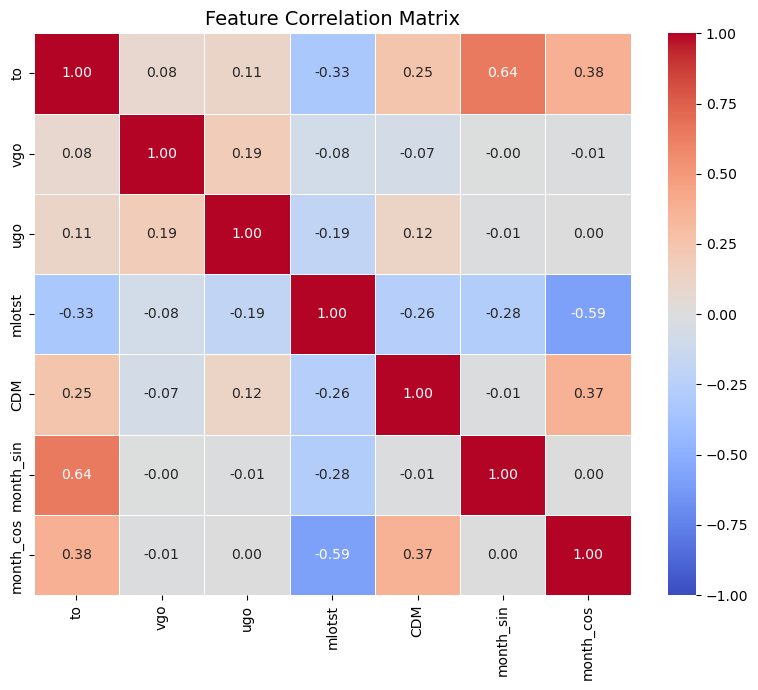

torch.Size([144, 12, 7, 62, 25])
torch.Size([144, 30, 17])
torch.Size([12, 12, 7, 62, 25])
torch.Size([12, 30, 17])


In [61]:
y = fishing
y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")



vars_ = [temp, 
        #  so,  zo, temp_bottom,
         ugo, vgo, mixed,
         cdm, #chl,  pp,
         month_sin, month_cos,
        #  year,
        # month,
        # moon_phase,
        # lat, lon,
        # depth,
        ]

if todas:
    vars_ = [temp, so,  zo, temp_bottom,
        ugo, vgo, mixed,
        cdm, chl,  pp,
        month_sin, month_cos,
        year,
        moon_phase,
        lat, lon,
        depth,
        ]


vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")
print(X.shape)
print(y.shape)
print(m.shape)



train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
val_x = X.sel(time=slice(f"{split_year}-01-01", f"{split_year_test-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year_test}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
val_y = y.sel(time=slice(f"{split_year}-01-01", f"{split_year_test-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year_test}-01-01", None))

m_train = m.sel(time=slice(None, f"{split_year-1}-12-31"))
m_val = m.sel(time=slice(f"{split_year}-01-01", f"{split_year_test-1}-12-31"))
m_test  = m.sel(time=slice(f"{split_year_test}-01-01", None))

# -------- Data Standardization (Z-score Normalization) --------
# 1. Assign your variable names to the channel coordinate for explicit targeting
train_X = train_X.assign_coords(channel=vars_names)
val_x = val_x.assign_coords(channel=vars_names)
test_X  = test_X.assign_coords(channel=vars_names)
epsilon = 1e-8 #avoids division by zero

# 2. Calculate mean and standard deviation across space and time
train_mean = train_X.mean(dim=["time", "lat", "lon"], skipna=True)
train_std  = train_X.std(dim=["time", "lat", "lon"], skipna=True)


# 3. Set mean=0 and std=1 for cyclical features so they bypass scaling
# (Subtracting 1e-8 ensures the denominator becomes exactly 1.0 when epsilon is added)
for feat in ["month_sin", "month_cos"]:
    if feat in train_mean.coords["channel"].values:
        train_mean.loc[dict(channel=feat)] = 0.0
        train_std.loc[dict(channel=feat)] = 1.0 - epsilon

# 4. Apply the transformation natively across the entire DataArray
train_X = (train_X - train_mean) / (train_std + epsilon)
val_x = (val_x - train_mean) / (train_std + epsilon)
test_X  = (test_X - train_mean) / (train_std + epsilon)


# -------- Check correlations --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
#inflation factor
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))
#correlation matrix
corr_matrix = df.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.75)]
print(f"Suggested variables to drop: {to_drop}")
plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True,cmap="coolwarm", fmt=".2f",vmin=-1,vmax=1, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()



def create_windows(X, y, m, window=12):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) #12 months
        y_seq.append(y_data[i+window]) #next month
        m_seq.append(m_data[i+window]) #next month
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12 #12 months

X_train, y_train, m_train = create_windows(train_X, train_y, m_train, window)
X_val, y_val, m_val = create_windows(val_x, val_y, m_val, window)
X_test, y_test, m_test = create_windows(test_X, test_y, m_test, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
print(X_test.shape)  # (N, T, C, H, W)
print(y_test.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val, m_val),
    batch_size=batch_size,
    shuffle=False
)


test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)



In [62]:
def prep_ml_data(X, y, m=None):
    """
    Converts 5D input tensors and 3D target tensors into 2D arrays 
    compatible with scikit-learn Random Forest. Handles both Torch tensors and Numpy arrays.
    """
    # Move to CPU and convert to numpy if dealing with PyTorch Tensors
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(m, torch.Tensor):
        m = m.detach().cpu().numpy()

    N = X.shape[0]
    
    # Flatten features: (N, T, C, H_x, W_x) -> (N, T * C * H_x * W_x)
    # For your train data: (72, 12, 11, 94, 48) -> (72, 595584)
    X_rf = X.reshape(N, -1)
    
    # Flatten targets: (N, H_y, W_y) -> (N, H_y * W_y)
    # For your train data: (72, 37, 20) -> (72, 740)
    y_rf = y.reshape(N, -1)
    
    if m is not None:
        m_rf = m.reshape(N, -1)
        return X_rf, y_rf, m_rf
    else:
        return X_rf, y_rf

X_train_ml, y_train_ml, m_train_ml = prep_ml_data(X_train, y_train, m_train)
X_val_ml, y_val_ml, m_val_ml = prep_ml_data(X_val, y_val, m_val)
X_test_ml, y_test_ml, m_test_ml = prep_ml_data(X_test, y_test, m_test)



H_val_test, W_val_test = y_val.shape[1], y_val.shape[2]
H_out_test, W_out_test = y_test.shape[1], y_test.shape[2]

m_true_val = m_val_ml.reshape(-1, H_val_test, W_val_test)
y_true_val = y_val_ml.reshape(-1, H_val_test, W_val_test)

m_true = m_test_ml.reshape(-1, H_out_test, W_out_test)
y_true = y_test_ml.reshape(-1, H_out_test, W_out_test)

mask_flat = m_test_ml.astype(bool)


In [63]:
def compute_metrics(y_test_ml, y_pred_flat, y_true, mask_spatial):

    # =====================================================
    # 1. FLATTEN FOR METRICS
    # =====================================================
    y_test_flat = y_test_ml.flatten()
    y_pred_flat = y_pred_flat.flatten()
    
    mask_spatial = mask_spatial.astype(bool)
    mask_flat = mask_spatial.flatten().astype(bool)
    

    y_test_masked = y_test_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)

    print("RMSE:", f"{rmse:.4f}")
    print(f"Normalized RMSE: {nrmse:.4f} ({nrmse*100:.2f}%)")
    print("MAE:", f"{mae:.4f}")
    print("R2:", f"{r2:.4f}")
    print("Pearson R:", f"{pearson_corr:.4f}")
    print("MBE:", f"{mbe:.4f}")
    print(f"Wasserstein Distance: {w_dist:.4f}")
    print(f"Spearman Rank Correlation: {spearman_corr:.2f}")

    # =====================================================
    # HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    hotspot_threshold_true = np.percentile(y_test_masked, percentile)
    hotspot_threshold_pred = np.percentile(y_pred_masked, percentile)

    # Create boolean masks for the top 20%
    actual_hotspots = (y_test_masked >= hotspot_threshold_true)
    pred_hotspots = (y_pred_masked >= hotspot_threshold_pred)

    # Count how many points are in the true top 20%
    total_actual_hotspots = np.sum(actual_hotspots)

    # Count how many points are in BOTH the true top 20% AND predicted top 20%
    shared_hotspots = np.sum(actual_hotspots & pred_hotspots)

    # Calculate the Hit Rate percentage
    hit_rate = shared_hotspots / total_actual_hotspots
    hit_rate_percent = hit_rate * 100

    print(f"\n--- Total hotspot Hit Rate (Top {100-percentile}% Overlap) ---")
    print(f"Hit Rate                        : {hit_rate_percent:.4f}%")

    # =====================================================
    # MONTHLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    
    # Rebuild 3D shape to iterate over time (months)
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D_temp = y_pred_flat.reshape(-1, H_out, W_out)
    
    total_actual_hotspots_all = 0
    shared_hotspots_all = 0
    monthly_hit_rates = []
    
    # Iterate through each month (time step)
    for i in range(y_true.shape[0]):
        
        # Handle the spatial mask safely (whether it is 2D or 3D)
        current_mask = mask_spatial[i] if mask_spatial.ndim == 3 else mask_spatial
        
        # Extract valid pixels strictly for this month
        y_true_month = y_true[i][current_mask]
        y_pred_month = y_pred3D_temp[i][current_mask]
        
        # Skip if mask leaves no valid pixels for this month
        if len(y_true_month) == 0:
            continue
            
        # Calculate the 80th percentile threshold for THIS specific month
        thresh_true = np.percentile(y_true_month, percentile)
        thresh_pred = np.percentile(y_pred_month, percentile)
        
        # Create boolean masks for the top 20%
        actual_hotspots_month = (y_true_month >= thresh_true)
        pred_hotspots_month = (y_pred_month >= thresh_pred)
        
        # Count overlaps
        total_actual = np.sum(actual_hotspots_month)
        shared = np.sum(actual_hotspots_month & pred_hotspots_month)
        
        # Keep running totals for the aggregate score
        total_actual_hotspots_all += total_actual
        shared_hotspots_all += shared
        
        # Calculate hit rate strictly for this month
        if total_actual > 0:
            monthly_hit_rates.append((shared / total_actual) * 100)

    mean_monthly_hit_rate = np.mean(monthly_hit_rates)
    print(f"Mean Monthly Hit Rate               : {mean_monthly_hit_rate:.3f}%")



    # =====================================================
    # YEARLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80

    yearly_hit_rates = []

    # Iterate through time in 12-month chunks
    for year_idx in range(0, y_true.shape[0], 12):
        end_idx = min(year_idx + 12, y_true.shape[0])

        if mask_spatial.ndim == 3:
            current_mask = mask_spatial[year_idx:end_idx].astype(bool)

            y_true_year = y_true[year_idx:end_idx][current_mask]
            y_pred_year = y_pred3D_temp[year_idx:end_idx][current_mask]

        else:
            current_mask = mask_spatial.astype(bool)

            y_true_year = y_true[year_idx:end_idx][:, current_mask].flatten()
            y_pred_year = y_pred3D_temp[year_idx:end_idx][:, current_mask].flatten()

        # Skip empty years
        if len(y_true_year) == 0:
            continue

        # Year-specific top 20% thresholds
        thresh_true_year = np.percentile(y_true_year, percentile)
        thresh_pred_year = np.percentile(y_pred_year, percentile)

        actual_hotspots_year = y_true_year >= thresh_true_year
        pred_hotspots_year = y_pred_year >= thresh_pred_year

        total_actual_year = np.sum(actual_hotspots_year)
        shared_year = np.sum(actual_hotspots_year & pred_hotspots_year)

        if total_actual_year > 0:
            yearly_hit_rates.append((shared_year / total_actual_year) * 100)

    mean_yearly_hit_rate = np.mean(yearly_hit_rates) if yearly_hit_rates else 0
    print(f"Mean Yearly Hit Rate                : {mean_yearly_hit_rate:.3f}%")
    print(f"-------------------------------------------------\n")

    # =====================================================
    # Reshape to 3D
    # =====================================================
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D = y_pred_flat.reshape(-1, H_out, W_out)
    mask_spatial = mask_spatial.astype(bool)

    # =====================================================
    # SSIM
    # =====================================================
    data_range = (y_true[mask_spatial].max()-y_true[mask_spatial].min())

    ssim_scores = []

    for i in range(y_true.shape[0]):

        _, ssim_map = ssim(
            y_true[i],
            y_pred3D[i],
            data_range=data_range,
            win_size=5,
            full=True
        )

        valid_ssim_pixels = ssim_map[mask_spatial[i]]

        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores)

    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # PLOTTING
    # =====================================================

    y_true_m = np.where(mask_spatial, y_true, 0)
    y_pred_m = np.where(mask_spatial, y_pred3D, 0)

    # 2. Compute means. The masked array automatically ignores the hidden values!
    y_pred_mean = y_pred_m.mean(axis=0)
    y_true_mean = y_true_m.mean(axis=0)
 
    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis') 
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Time Series Plot
    # -----------------------------------------------------
    y_true_m2 = ma.masked_where(~mask_spatial, y_true)
    y_pred_m2 = ma.masked_where(~mask_spatial, y_pred3D)
    y_pred_plot2 = y_pred_m2.mean(axis=(1, 2))
    y_true_plot2 = y_true_m2.mean(axis=(1, 2))
    
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(y_true_plot2, label="Real")
    ax.plot(y_pred_plot2, label="Predicho")
    ax.set_ylabel("Valor Promedio")
    
    ax.annotate(f"R2: {r2_plot2:.3f}",xy=(0.98, 0.02),xycoords="axes fraction",ha="right",va="bottom",)
    ax.set_xlabel("Tiempo (Meses)")
    ax.legend()

    plt.show()
    
    metrics = [r2, pearson_corr, r2_plot2, mean_ssim, rmse, nrmse, mae, mbe, w_dist, spearman_corr, hit_rate_percent, mean_yearly_hit_rate, mean_monthly_hit_rate]
    columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr", "hit_rate_percent", "mean_yearly_hit_rate", "mean_monthly_hit_rate"]
    metrics_df = pd.DataFrame(columns=columns)
    metrics_df.loc[len(metrics_df)] = metrics

    return metrics_df, fig

Validation R2: 0.5529
RMSE: 1.9043
Normalized RMSE: 0.1948 (19.48%)
MAE: 1.3214
R2: 0.5174
Pearson R: 0.7579
MBE: -0.5678
Wasserstein Distance: 1.0613
Spearman Rank Correlation: 0.72

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                        : 48.6667%
Mean Monthly Hit Rate               : 34.685%
Mean Yearly Hit Rate                : 48.667%
-------------------------------------------------

Mean Masked SSIM: 0.5030



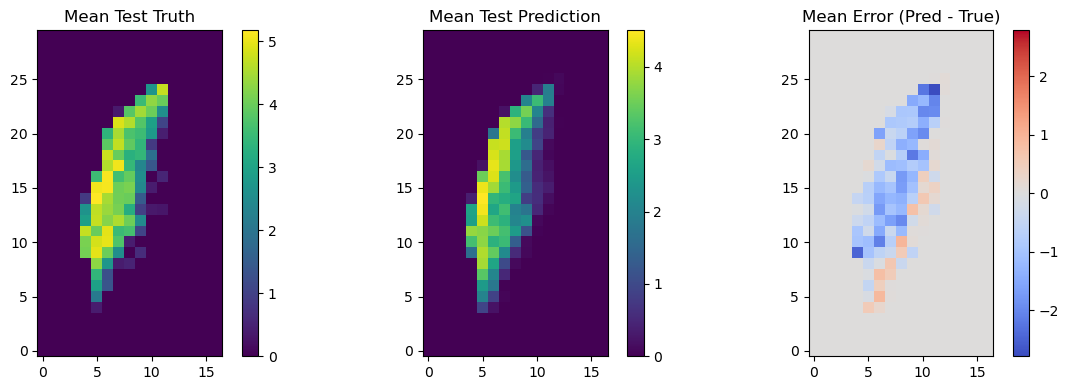

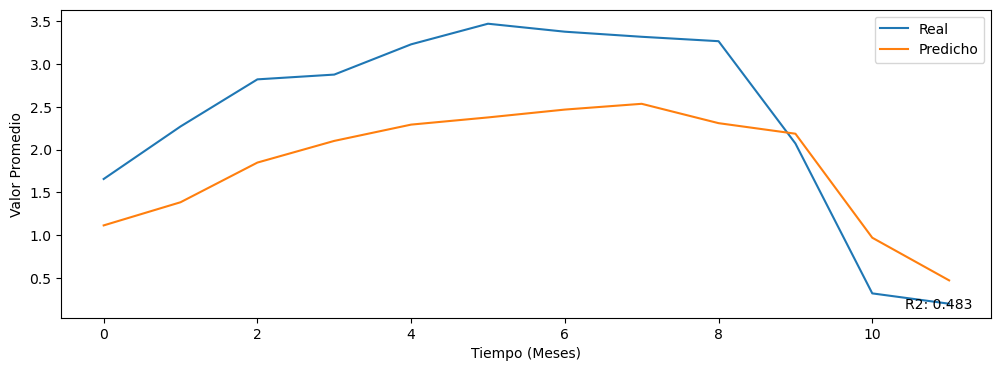

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate,val_r2
0,0.517368,0.75787,0.482674,0.502982,1.904328,0.194792,1.321373,-0.567788,1.06126,0.719726,48.666667,48.666667,34.684685,0.552869


    Variable  Importance
0         to    0.274760
1     mlotst    0.193368
2        CDM    0.180082
3        ugo    0.145188
4        vgo    0.138950
5  month_cos    0.034027
6  month_sin    0.033624


In [64]:
model = RandomForestRegressor(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=42)

model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

# compute R2 on validation set only for saving it
y_pred_val_flat = model.predict(X_val_ml)
y_pred_val_flat = y_pred_val_flat.flatten()
y_val_flat = y_val_ml.flatten()

mask_spatial = m_true_val.astype(bool)
mask_flat = mask_spatial.flatten().astype(bool)

y_val_flat_masked = y_val_flat[mask_flat]
y_pred_val_flat_masked = y_pred_val_flat[mask_flat]

val_r2 = r2_score(y_val_flat_masked, y_pred_val_flat_masked)
print("Validation R2:", f"{val_r2:.4f}")
#-------------------------------------------------------------------------------


metrics_df, fig = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
metrics_df['val_r2'] = val_r2

display(metrics_df)

# -------- Feature Importance Extraction --------
raw_importances = model.feature_importances_
T = X_train.shape[1]   # window (12)
C = X_train.shape[2]   # number of variables/channels
H_x = X_train.shape[3] # height (lat)
W_x = X_train.shape[4] # width (lon)

reshaped_importances = raw_importances.reshape(T, C, H_x, W_x)

variable_importances = reshaped_importances.sum(axis=(0, 2, 3))


importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Importance': variable_importances
})

# Sort in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
print(importance_df)

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
ax = fig.axes[0]
ax.set_title(f"Serie temporal de {model_name}")
fig.canvas.draw()


img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"{model_name}_{sp}"
if todas:
    sheet_name = f"{model_name}_{sp}_todas"

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    importance_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_df) + 3, index=False)
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")


Validation R2: 0.5360
RMSE: 1.9052
Normalized RMSE: 0.1949 (19.49%)
MAE: 1.3069
R2: 0.5169
Pearson R: 0.7586
MBE: -0.5902
Wasserstein Distance: 1.0445
Spearman Rank Correlation: 0.72

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                        : 47.0000%
Mean Monthly Hit Rate               : 34.760%
Mean Yearly Hit Rate                : 47.000%
-------------------------------------------------

Mean Masked SSIM: 0.5024



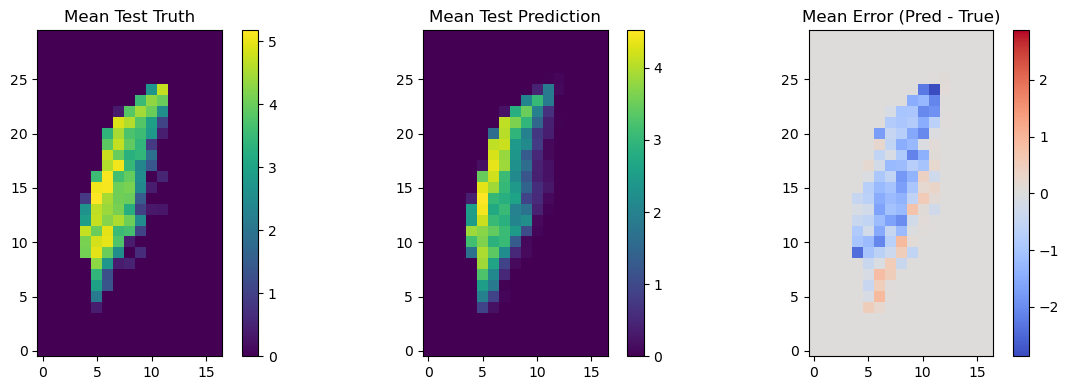

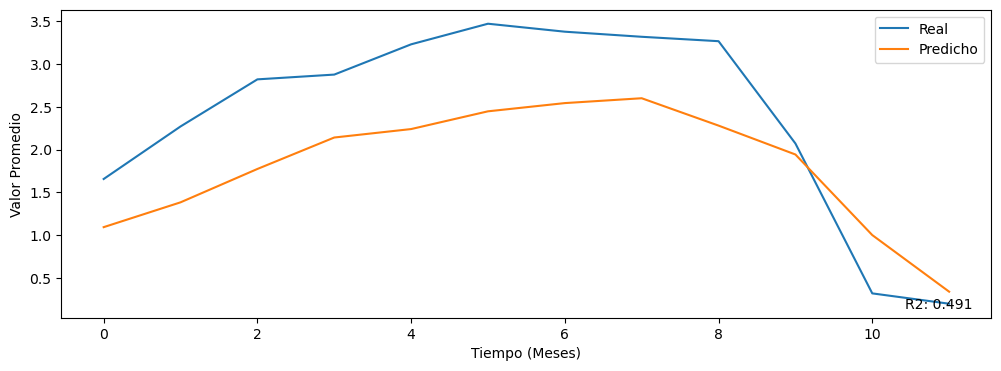

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.516906,0.7586,0.49083,0.502404,1.905237,0.194885,1.306909,-0.590188,1.044515,0.721917,47.0,47.0,34.75976


In [65]:
model = ExtraTreesRegressor(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=42)
model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

# compute R2 on validation set only for saving it
y_pred_val_flat = model.predict(X_val_ml)
y_pred_val_flat = y_pred_val_flat.flatten()
y_val_flat = y_val_ml.flatten()

mask_spatial = m_true_val.astype(bool)
mask_flat = mask_spatial.flatten().astype(bool)

y_val_flat_masked = y_val_flat[mask_flat]
y_pred_val_flat_masked = y_pred_val_flat[mask_flat]

val_r2 = r2_score(y_val_flat_masked, y_pred_val_flat_masked)
print("Validation R2:", f"{val_r2:.4f}")
#-------------------------------------------------------------------------------

metrics_df, fig = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
display(metrics_df)

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
ax = fig.axes[0]
ax.set_title(f"Serie temporal de {model_name}")
fig.canvas.draw()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"{model_name}_{sp}"
if not todas:
    with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

    with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
        ws = writer.sheets[sheet_name]
        img1 = Image(img_buffer1)
        ws.add_image(img1, f"N1")

Validation R2: 0.5372
RMSE: 1.9309
Normalized RMSE: 0.1975 (19.75%)
MAE: 1.2985
R2: 0.5038
Pearson R: 0.7477
MBE: -0.5968
Wasserstein Distance: 1.0344
Spearman Rank Correlation: 0.71

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                        : 47.0000%
Mean Monthly Hit Rate               : 34.018%
Mean Yearly Hit Rate                : 47.000%
-------------------------------------------------

Mean Masked SSIM: 0.4916



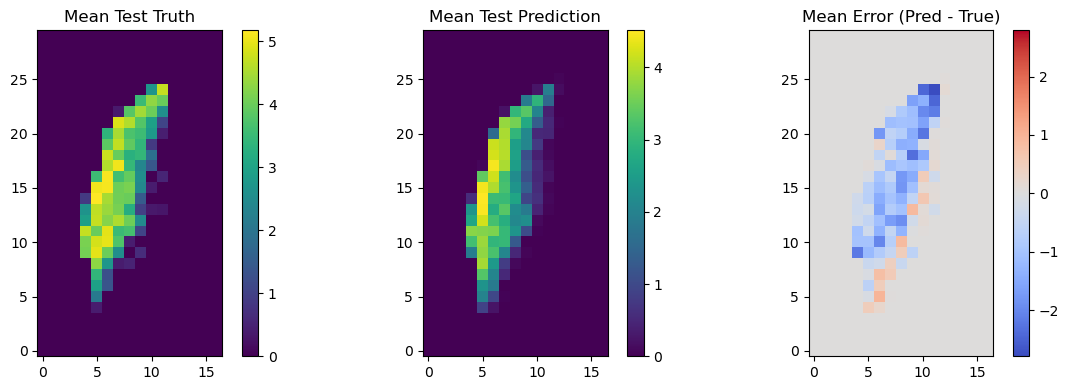

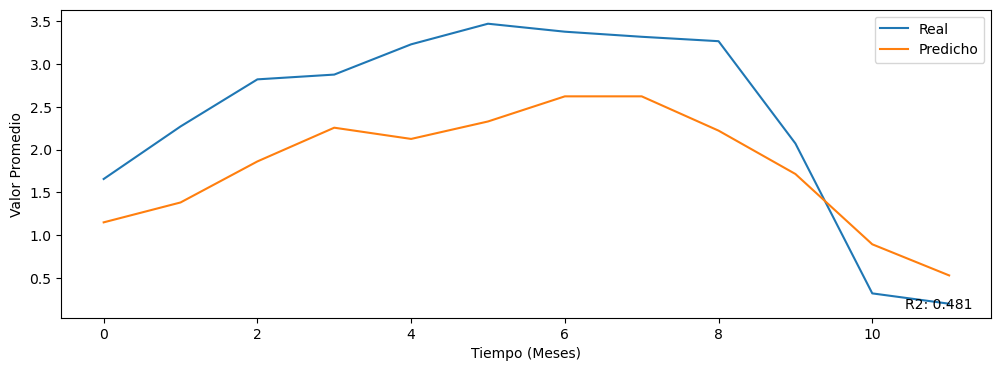

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.503797,0.747691,0.481477,0.491592,1.930915,0.197511,1.298503,-0.596835,1.034419,0.714518,47.0,47.0,34.018018


In [66]:
model = KNeighborsRegressor(n_neighbors=10, weights='distance', n_jobs=-1)
model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

# compute R2 on validation set only for saving it
y_pred_val_flat = model.predict(X_val_ml)
y_pred_val_flat = y_pred_val_flat.flatten()
y_val_flat = y_val_ml.flatten()

mask_spatial = m_true_val.astype(bool)
mask_flat = mask_spatial.flatten().astype(bool)

y_val_flat_masked = y_val_flat[mask_flat]
y_pred_val_flat_masked = y_pred_val_flat[mask_flat]

val_r2 = r2_score(y_val_flat_masked, y_pred_val_flat_masked)
print("Validation R2:", f"{val_r2:.4f}")
#-------------------------------------------------------------------------------

metrics_df, fig = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
display(metrics_df)

# save everyhtng to a excel workbook
model_name = model.__class__.__name__
ax = fig.axes[0]
ax.set_title(f"Serie temporal de {model_name}")
fig.canvas.draw()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"{model_name}_{sp}"
if not todas:
    with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

    with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
        ws = writer.sheets[sheet_name]
        img1 = Image(img_buffer1)
        ws.add_image(img1, f"N1")



Validation R2: 0.4725
RMSE: 2.0027
Normalized RMSE: 0.2048 (20.48%)
MAE: 1.3812
R2: 0.4662
Pearson R: 0.6970
MBE: -0.3563
Wasserstein Distance: 0.9262
Spearman Rank Correlation: 0.66

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Hit Rate                        : 43.3333%
Mean Monthly Hit Rate               : 32.168%
Mean Yearly Hit Rate                : 43.333%
-------------------------------------------------

Mean Masked SSIM: 0.4879



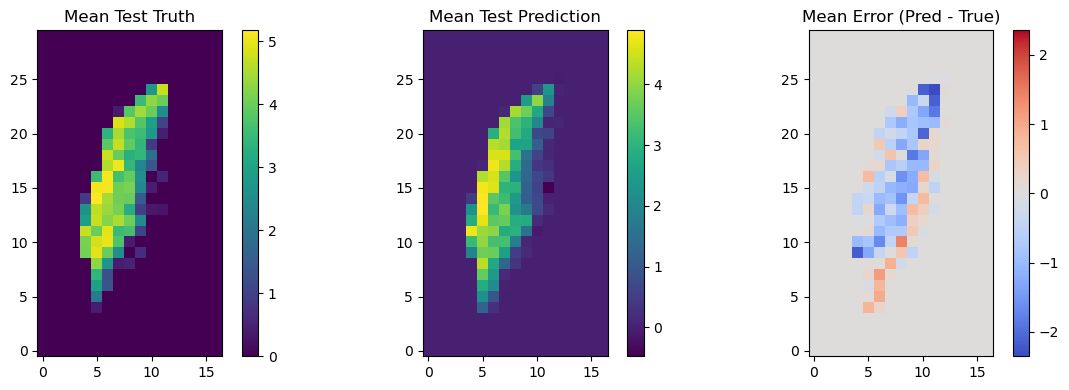

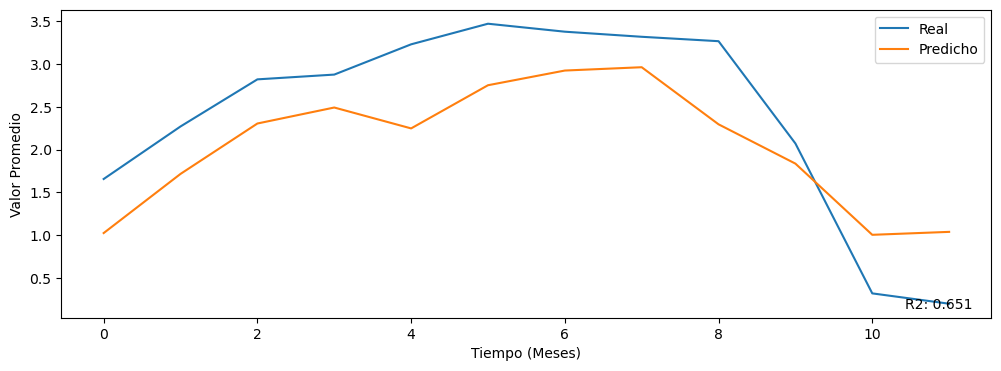

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr,hit_rate_percent,mean_yearly_hit_rate,mean_monthly_hit_rate
0,0.46624,0.696995,0.651094,0.4879,2.002656,0.20485,1.381199,-0.356263,0.926181,0.660619,43.333333,43.333333,32.168168


Running 50 bootstrap iterations

--- Ridge (L2) Bootstrapped Significance Report ---
    Variable  Significant_Grid_Ratio  Overall_Impact     Direction
5  month_sin                0.500000        0.062872  Negative (-)
6  month_cos                0.500000        0.062872  Negative (-)
0         to                0.267957        0.225716  Positive (+)
4        CDM                0.246452        0.672737  Negative (-)
3     mlotst                0.221398        0.532658  Negative (-)
2        ugo                0.168441        0.479848  Negative (-)
1        vgo                0.152849        0.347598  Positive (+)

--- Overall Importance monthly ---


,to,vgo,ugo,mlotst,CDM,month_sin,month_cos
Month_lag_1,0.000009,0.000021,0.000025,0.000020,0.000055,5.298403e-06,5.073994e-07
Month_lag_2,0.000008,0.000015,0.000025,0.000020,0.000035,4.334852e-06,3.088624e-06
Month_lag_3,0.000018,0.000015,0.000025,0.000036,0.000034,2.209779e-06,4.842253e-06
Month_lag_4,0.000008,0.000018,0.000026,0.000030,0.000034,5.073994e-07,5.298403e-06
Month_lag_5,0.000006,0.000020,0.000025,0.000024,0.000036,3.088624e-06,4.334852e-06
Month_lag_6,0.000017,0.000017,0.000027,0.000022,0.000048,4.842253e-06,2.209779e-06
Month_lag_7,0.000015,0.000022,0.000030,0.000026,0.000034,5.298403e-06,5.073994e-07
Month_lag_8,0.000014,0.000023,0.000025,0.000036,0.000031,4.334852e-06,3.088624e-06
Month_lag_9,0.000011,0.000020,0.000024,0.000044,0.000036,2.209779e-06,4.842253e-06
Month_lag_10,0.000010,0.000020,0.000026,0.000034,0.000032,5.073994e-07,5.298403e-06



--- Overall direction monthly ---


,to,vgo,ugo,mlotst,CDM,month_sin,month_cos
Month_lag_1,0.000009,0.000021,0.000025,0.000020,0.000055,5.298403e-06,5.073994e-07
Month_lag_2,0.000008,0.000015,0.000025,0.000020,0.000035,4.334852e-06,3.088624e-06
Month_lag_3,0.000018,0.000015,0.000025,0.000036,0.000034,2.209779e-06,4.842253e-06
Month_lag_4,0.000008,0.000018,0.000026,0.000030,0.000034,5.073994e-07,5.298403e-06
Month_lag_5,0.000006,0.000020,0.000025,0.000024,0.000036,3.088624e-06,4.334852e-06
Month_lag_6,0.000017,0.000017,0.000027,0.000022,0.000048,4.842253e-06,2.209779e-06
Month_lag_7,0.000015,0.000022,0.000030,0.000026,0.000034,5.298403e-06,5.073994e-07
Month_lag_8,0.000014,0.000023,0.000025,0.000036,0.000031,4.334852e-06,3.088624e-06
Month_lag_9,0.000011,0.000020,0.000024,0.000044,0.000036,2.209779e-06,4.842253e-06
Month_lag_10,0.000010,0.000020,0.000026,0.000034,0.000032,5.073994e-07,5.298403e-06


In [ ]:
alpha = 100
solver = "svd"
ridge_model = Ridge(alpha=alpha, solver=solver, random_state=42)
ridge_model.fit(X_train_ml, y_train_ml)

y_pred_flat = ridge_model.predict(X_test_ml)

# compute R2 on validation set only for saving it
y_pred_val_flat = ridge_model.predict(X_val_ml)
y_pred_val_flat = y_pred_val_flat.flatten()
y_val_flat = y_val_ml.flatten()

mask_spatial = m_true_val.astype(bool)
mask_flat = mask_spatial.flatten().astype(bool)

y_val_flat_masked = y_val_flat[mask_flat]
y_pred_val_flat_masked = y_pred_val_flat[mask_flat]

val_r2 = r2_score(y_val_flat_masked, y_pred_val_flat_masked)
print("Validation R2:", f"{val_r2:.4f}")
#-------------------------------------------------------------------------------

metrics_df, fig = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
display(metrics_df)

# -------- Bootstrapping for Statistical metrics --------
# warnings.filterwarnings("ignore", message="Singular matrix in solving dual problem") # Suppress the specific warning 

n_iterations = 50  
n_features = X_train_ml.shape[1]
bootstrapped_coefs = np.zeros((n_iterations, n_features), dtype=np.float32)

print(f"Running {n_iterations} bootstrap iterations")

for i in range(n_iterations):
    X_boot, y_boot = resample(X_train_ml, y_train_ml, random_state=i)
    boot_model = Ridge(alpha=alpha, solver=solver, random_state=i)
    boot_model.fit(X_boot, y_boot)
    bootstrapped_coefs[i, :] = boot_model.coef_.mean(axis=0)

# -------- Advanced Statistical Feature Extraction (Confidence Intervals) --------

# Calculate the 2.5th and 97.5th percentiles to build a 95% Confidence Interval
# This acts as our mathematical surrogate for a two-tailed p < 0.05 threshold
lower_bound = np.percentile(bootstrapped_coefs, 2.5, axis=0)
upper_bound = np.percentile(bootstrapped_coefs, 97.5, axis=0)

# A feature is statistically stable/significant if its 95% CI does not cross zero
# (meaning it is strictly positive or strictly negative across 95% of resamples)
is_significant = (lower_bound > 0) | (upper_bound < 0)

# -------- Reshaping & Grid Aggregation --------

# Extract and average coefficients from your baseline full-dataset model
raw_ridge_coefs = ridge_model.coef_.mean(axis=0)

# Reshape both baseline weights and the significance mask back to the 5D spatiotemporal grid
reshaped_ridge_coefs = raw_ridge_coefs.reshape(T, C, H_x, W_x)
reshaped_significance = is_significant.reshape(T, C, H_x, W_x)

# Calculate final aggregated metrics across dimensions (T, H_x, W_x)
# Significant_Grid_Ratio: % of the spatiotemporal domain where the variable is significant
significant_grid_ratio = reshaped_significance.mean(axis=(0, 2, 3))
global_ridge_weights = np.abs(reshaped_ridge_coefs).sum(axis=(0, 2, 3))
global_ridge_direction = np.sign(reshaped_ridge_coefs.mean(axis=(0, 2, 3)))

direction_labels = ['Positive (+)' if d > 0 else 'Negative (-)' for d in global_ridge_direction]

# Compile the final statistical report
ridge_importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Significant_Grid_Ratio': significant_grid_ratio,
    'Overall_Impact': global_ridge_weights,
    'Direction': direction_labels
})

print("\n--- Ridge (L2) Bootstrapped Significance Report ---")
print(ridge_importance_df.sort_values(by='Significant_Grid_Ratio', ascending=False))

coefs_by_month = np.abs(reshaped_ridge_coefs).mean(axis=(2, 3))
significance_by_month = reshaped_significance.mean(axis=(2, 3))*10000
direction_by_month = np.sign(reshaped_ridge_coefs.mean(axis=(2, 3)))
direction_labels_by_month = np.where(direction_by_month > 0, '(+)', '(-)')

print("\n--- Overall Importance monthly ---")
ridge_importance_df_monthly = pd.DataFrame(coefs_by_month, columns=vars_names)
ridge_importance_df_monthly.index = [f"Month_lag_{i+1}" for i in range(T)]
display(ridge_importance_df_monthly)

print("\n--- Overall direction monthly ---")
ridge_direction_df_monthly = pd.DataFrame(direction_labels_by_month, columns=vars_names)
ridge_direction_df_monthly.index = [f"Month_lag_{i+1}" for i in range(T)]
display(ridge_direction_df_monthly)

# save everyhtng to a excel workbook
model_name = ridge_model.__class__.__name__
ax = fig.axes[0]
ax.set_title(f"Serie temporal de {model_name}")
fig.canvas.draw()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)
sheet_name = f"{model_name}_{sp}"
if todas:
    sheet_name = f"{model_name}_{sp}_ALL"
with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)

with pd.ExcelWriter("./modelos/resultados/Regre/ML_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    ridge_importance_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_df) + 3, index=False)
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")